# **Load Dataset into Model**
Note: Google Colab offers T4 GPU for 12 hours runtime which can handle 30 Billion parameters.
Kaggle offers 2xT4 GPU for 12 hours runtime which can handle 60 Billion parameters.
We can atmost handle gpt-2, gemma 2, DeepSeek‑Coder, LLaMA 2

In [ ]:

import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import sys
print(sys.version)
print(tf.__version__)
fashion_mnist = tf.keras.datasets.fashion_mnist #70k images: 60k for training, 10k for validation.
(training_images, training_labels), (test_images, test_labels) = fashion_mnist.load_data()
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
training_images.shape #60k images. 28x28 pixels. Each value is rgb (0-255) Grayscale
#Preprocess Data to make it (0-1) from (0-255)
training_images = training_images / 255.0
test_images = test_images / 255.0
#Build Model
model = tf.keras.Sequential([
tf.keras.layers.Flatten(input_shape=(28, 28)), #Input Layer
tf.keras.layers.Dense(128, activation='relu'), #Hidden Layer
tf.keras.layers.Dense(10) #output Layer
])

3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
2.19.0
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# **Training Model**

In [ ]:
model.compile( #Hyperparameter tuning
optimizer='adam',
loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
metrics=['accuracy']
)
model.fit(training_images, training_labels, epochs=10)
model.evaluate(test_images, test_labels) #[Loss, Accuracy] Goal: Loss decrease and Accuracy increases

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6547 - loss: 10.1339
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7132 - loss: 0.7858
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7290 - loss: 0.6993
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7424 - loss: 0.6468
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7600 - loss: 0.6126
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7990 - loss: 0.5713
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8088 - loss: 0.5567
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8152 - loss: 0.5453
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8233 - loss: 0.5254
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8239 - loss: 0.5253
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8062 - loss: 0.5803


[0.5966686606407166, 0.8008999824523926]

# **Predict Model**

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


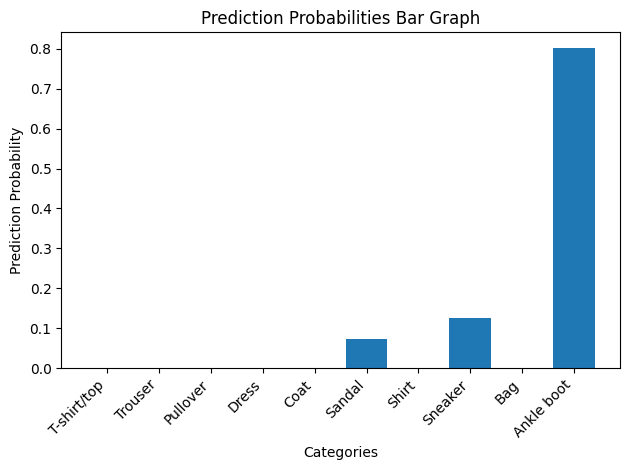

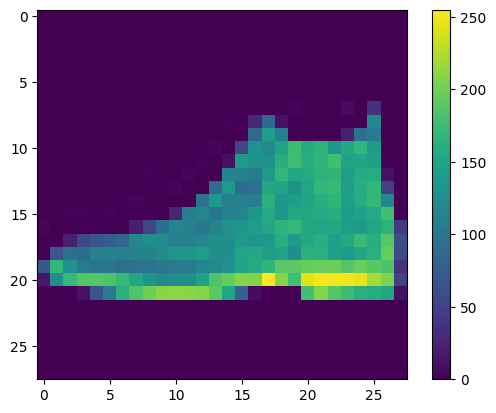

In [ ]:
probability_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])
predictions = probability_model.predict(test_images)
predictions[0] #Prediction of the first image for each category
print(class_names[np.argmax(predictions[0])]) #Highest prediction category
# test_labels[0] Actual category
plt.bar(class_names, predictions[0])
plt.xlabel('Categories')
plt.ylabel('Prediction Probability')
plt.title('Prediction Probabilities Bar Graph')
plt.xticks(rotation=45, ha='right') # Rotate labels
plt.tight_layout() # Adjust layout
plt.show()
plt.figure()
plt.imshow(test_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

In [ ]:
#Create tensors with tf.constant()
scalar = tf.constant(7)
#Check the number of dimensions of a tensor
print(scalar.ndim)
scalar

0


<tf.Tensor: shape=(), dtype=int32, numpy=7>

In [ ]:
#Create a vector
vector = tf.constant([10,10])
#Check the number of dimensions of a vector
print(vector.ndim)
vector

1


<tf.Tensor: shape=(2,), dtype=int32, numpy=array([10, 10], dtype=int32)>

# **Tensor attributes:**
* dtype - datatype
* ndim - dimensions
* shape - Shapen
* tf.size() - # elements in tensor


In [ ]:
#Create a matrix
matrix = tf.constant([[10,7],[7,10]])
#Check the number of dimensions of a matrix
print(matrix.ndim)
matrix

2


<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[10,  7],
       [ 7, 10]], dtype=int32)>

In [ ]:
another_matrix = tf.constant([[10.,7.],[3.,2.],[8.,9.]], dtype=tf.float16)
print(another_matrix.ndim)
another_matrix

2


<tf.Tensor: shape=(3, 2), dtype=float16, numpy=
array([[10.,  7.],
       [ 3.,  2.],
       [ 8.,  9.]], dtype=float16)>

In [ ]:
tensor = tf.constant([[[1,2,3],[4,5,6]],[[7,8,9],[10,11,12]],[[13,14,15],[16,17,18]]])
print(tensor.ndim)
tensor

3


<tf.Tensor: shape=(3, 2, 3), dtype=int32, numpy=
array([[[ 1,  2,  3],
        [ 4,  5,  6]],

       [[ 7,  8,  9],
        [10, 11, 12]],

       [[13, 14, 15],
        [16, 17, 18]]], dtype=int32)>

In [ ]:
changeable_tensor = tf.Variable([10,7])
unchangeable_tensor = tf.constant([10,7]) #You cannot assign new values to tensor
changeable_tensor, unchangeable_tensor

(<tf.Variable 'Variable:0' shape=(2,) dtype=int32, numpy=array([10,  7], dtype=int32)>,
 <tf.Tensor: shape=(2,), dtype=int32, numpy=array([10,  7], dtype=int32)>)

In [ ]:
changeable_tensor[0].assign(7)
changeable_tensor

<tf.Variable 'Variable:0' shape=(2,) dtype=int32, numpy=array([7, 7], dtype=int32)>

In [ ]:
#Pseudo-random based on seed
random_1 = tf.random.Generator.from_seed(42)
random_1 = random_1.normal(shape=(3,2))
random_1

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[-0.7565803 , -0.06854702],
       [ 0.07595026, -1.2573844 ],
       [-0.23193765, -1.8107855 ]], dtype=float32)>

In [ ]:
not_shuffled = tf.constant([[10,7],[3,4],[2,5]])
shuffled = tf.random.shuffle(not_shuffled)
tf.zeros(shape=(3,4)) # Fill 0s in the tensor

<tf.Tensor: shape=(3, 4), dtype=float32, numpy=
array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]], dtype=float32)>

In [ ]:
#TensorFlow runs on GPU, NumPy runs on CPU
numpy_A = np.arange(1, 25, dtype=np.int32)
tensor_A = tf.constant(numpy_A, shape=(2,3,4))
tensor_A
#Reshape tensorA
#tf.reshape(tensor_A, shape=(3,2))
#Transpose
#tf.transpose(tensor_A)
#Change datatype
# X = tf.cast(tensor_A, dtype=tf.float32)

<tf.Tensor: shape=(2, 3, 4), dtype=int32, numpy=
array([[[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12]],

       [[13, 14, 15, 16],
        [17, 18, 19, 20],
        [21, 22, 23, 24]]], dtype=int32)>

In [ ]:
tensor_A[:2, :2, :2] #Index first 2 elements in each dimension
#Add an extra dimension
rank_3_tensor = tensor_A[..., tf.newaxis]
# tf.expand_dims(tensor_A, axis=-1)

<tf.Tensor: shape=(2, 2, 2), dtype=int32, numpy=
array([[[ 1,  2],
        [ 5,  6]],

       [[13, 14],
        [17, 18]]], dtype=int32)>

In [ ]:
#Operations apply to every element in tensor
tensor = tf.constant([[10,7],[3,4]])
tensor + 10
tensor * 10
tf.multiply(tensor, 10)
#Multiplication of elements
tensor * tensor
#Matrix multiplication (Dot Product)
#Note: (axb) * (bxc) for valid operation
tf.matmul(tensor, tensor)
# tensor @ tensor

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[121,  98],
       [ 42,  37]], dtype=int32)>